# Clustering Stratifié pour le Split Train / Test

**Objectif** : garantir un split train/test **représentatif** du stock résidentiel en effectuant un clustering
indépendant sur chaque groupe métier, puis en agrégeant les labels pour construire un stratum composite.

**Pipeline** :
1. Clustering KMeans par groupe de features (7 groupes)
2. Analyse de chaque clustering (elbow, silhouette, centroïdes)
3. Agrégation → stratum composite
4. `train_test_split(stratify=stratum)` équilibré
5. Sauvegarde des indices

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

RANDOM_STATE = 42
TEST_SIZE    = 0.20

print('Libs OK')

Libs OK


## 1. Chargement des données

In [2]:
X = pd.read_parquet(DATA_PROCESSED / 'X.parquet')
Y = pd.read_parquet(DATA_PROCESSED / 'Y.parquet')

print(f'X : {X.shape}  |  Y : {Y.shape}')
print(f'NaN dans X : {X.isna().sum().sum()}')
X.dtypes.value_counts()

X : (549971, 108)  |  Y : (549971, 5)
NaN dans X : 0


int64      34
float32    26
float64    23
Int8       16
int8        9
Name: count, dtype: int64

## 2. Définition des groupes de features

In [3]:

GROUPES = {

    # ── G1 : Socio-Économiques ────────────────────────────────────────────────
    'G1_SocioEco': [
        'in.income',
        'in.tenure',
    ],

    # ── G2 : Occupants ────────────────────────────────────────────────────────
    'G2_Occupants': [
        'in.occupants',
        'in.vacancy_status',
        'in.usage_level',
    ],

    # ── G3 : Météo → zone ASHRAE directement (pas KMeans) ────────────────────
    # Chargé depuis metadata_clean.parquet : in.ashrae_iecc_climate_zone_2004

    # ── G4a : Isolation & Étanchéité ─────────────────────────────────────────
    'G4a_Isolation': [
        'in.insulation_ceiling',
        'in.insulation_wall',
        'in.insulation_roof',
        'in.insulation_floor',
        'in.insulation_foundation_wall',
        'in.air_leakage_to_outside_ach50',
        'in.window_ufactor',
        'in.window_shgc',
        'in.window_front',
        'in.roof_material',
    ],

    # ── G4b : Géométrie & Voisinage ───────────────────────────────────────────
    'G4b_Geometrie': [
        'in.geometry_floor_area',
        'in.vintage',
        'in.geometry_stories',
        'in.geometry_attic_type',
        'in.geometry_foundation_type',
        'in.geometry_garage',
        'in.bedrooms',
        'in.corridor',
        'in.orientation_sin',
        'in.orientation_cos',
        'in.horiz_loc_Middle',
        'in.horiz_loc_Right',
        'in.neighbor_distance_ft',
        'in.neighbor_both_sides',
    ],

    # ── G5a : HVAC ────────────────────────────────────────────────────────────
    'G5a_HVAC': [
        'in.hvac_has_ducts',
        'in.heating_setpoint',
        'in.cooling_setpoint',
        'in.hvac_cooling_efficiency',
        'in.hvac_has_zonal_electric_heating',
        'in.cooling_setpoint_has_offset',
        'in.heating_setpoint_has_offset',
        'in.cooling_setpoint_offset_magnitude',
        'in.heating_setpoint_offset_magnitude',
        'in.hvac_cooling_partial_space_conditioning',
        'in.duct_location_int',
        'in.duct_leakage',
        'in.duct_insulation',
    ],

    # ── G5b : ECS / Chauffe-eau ───────────────────────────────────────────────
    'G5b_ECS': [
        'in.water_heater_efficiency',
        'in.water_heater_fuel_natural_gas',
        'in.water_heater_technology_storage',
        'in.water_heater_technology_tankless',
        'in.water_heater_location_unconditioned',
        'in.water_heater_location_semi_conditioned',
        'in.water_heater_technology_indirect',
        'in.water_heater_fuel_propane',
        'in.water_heater_in_unit',
        'in.hot_water_fixtures',
    ],

    # ── G6 : Usages Blancs (électroménager) ──────────────────────────────────
    'G6_UsagesBlancs': [
        'in.clothes_dryer_efficiency', 'in.clothes_dryer_has',
        'in.clothes_dryer_electric',   'in.clothes_dryer_gas',
        'in.clothes_dryer_usage_level',
        'in.clothes_washer_efficiency', 'in.clothes_washer_has',
        'in.refrigerator_ef', 'in.refrigerator_has',
        'in.refrigerator_usage_level',
        'in.misc_extra_refrigerator_ef', 'in.misc_extra_refrigerator_has',
        'in.misc_freezer_ef',
        'in.lighting_efficiency',
        'in.has_well_pump',
        'in.has_ceiling_fan', 'in.ceiling_fan_used',
        'in.dishwasher_kwh',  'in.has_dishwasher',
    ],

    # ── G7 : Usages Bruns (TV, PC, chargeurs) ────────────────────────────────
    'G7_UsagesBruns': [
        'in.plug_loads',
        'in.plug_load_diversity',
    ],
}

# Verification
all_cols = [c for cols in GROUPES.values() for c in cols]
manquantes = [c for c in all_cols if c not in X.columns]
print(f'Colonnes definies : {len(all_cols)}  |  Manquantes : {manquantes}')
print()
for g, cols in GROUPES.items():
    cols_ok = [c for c in cols if c in X.columns]
    print(f'{g:22s} : {len(cols_ok):3d} features')
print(f'\nTotal features pour le clustering : {len(all_cols)} / {len(X.columns)}')


Colonnes definies : 73  |  Manquantes : []

G1_SocioEco            :   2 features
G2_Occupants           :   3 features
G4a_Isolation          :  10 features
G4b_Geometrie          :  14 features
G5a_HVAC               :  13 features
G5b_ECS                :  10 features
G6_UsagesBlancs        :  19 features
G7_UsagesBruns         :   2 features

Total features pour le clustering : 73 / 108


In [4]:
# Verification : couverture des attributs de X.parquet
x_cols       = set(X.columns)
grouped_cols = set(c for cols in GROUPES.values() for c in cols)

non_assigned   = sorted(x_cols - grouped_cols)
missing_from_x = sorted(grouped_cols - x_cols)

print(f"X.parquet             : {len(x_cols)} colonnes")
print(f"Colonnes dans GROUPES : {len(grouped_cols)}")
print()

if non_assigned:
    print(f"[WARN] Dans X mais NON assignees a un groupe ({len(non_assigned)}) :")
    for c in non_assigned:
        print(f"   - {c}")
else:
    print("[OK] Toutes les colonnes de X sont assignees a un groupe.")

print()

if missing_from_x:
    print(f"[WARN] Dans GROUPES mais ABSENTES de X ({len(missing_from_x)}) :")
    for c in missing_from_x:
        print(f"   - {c}")
else:
    print("[OK] Toutes les colonnes des groupes existent dans X.")

print()
print("-- Detail par groupe ------------------------------------------")
total = 0
for g, cols in GROUPES.items():
    ok     = [c for c in cols if c in x_cols]
    ko     = [c for c in cols if c not in x_cols]
    status = "OK" if not ko else "MANQUE"
    manque = f"  | MANQUE : {ko}" if ko else ""
    print(f"  [{status:6s}]  {g:22s} : {len(ok):3d}/{len(cols)} features{manque}")
    total += len(ok)
print(f"\n  Total features pour le clustering : {total} / {len(x_cols)}")


X.parquet             : 108 colonnes
Colonnes dans GROUPES : 73

[WARN] Dans X mais NON assignees a un groupe (35) :
   - in.aiannh_area
   - in.area_median_income
   - in.electric_panel_breaker_space_total_count
   - in.electric_panel_service_rating..a
   - in.electric_vehicle_charge_at_home
   - in.electric_vehicle_charger
   - in.electric_vehicle_miles_traveled
   - in.federal_poverty_level
   - in.has_hot_tub
   - in.has_pool
   - in.has_pv
   - in.hot_tub_electric
   - in.household_has_tribal_persons
   - in.misc_gas_fireplace_present
   - in.misc_gas_grill_present
   - in.misc_gas_lighting_present
   - in.misc_hot_tub_gas
   - in.pool_heater_electric
   - in.pool_heater_gas
   - in.pool_heater_present
   - in.pv_system_size
   - in.slab_perimeter_r
   - in.slab_under_r
   - in.state_metro_median_income
   - in.wall_exterior_finish_r
   - in.wall_finish_brick
   - in.wall_finish_dark
   - in.wall_finish_none
   - in.wall_finish_shingle
   - in.wall_finish_stucco
   - in.wall_finis

## 3. Fonctions utilitaires

In [5]:
def elbow_silhouette(X_scaled, k_range=range(2, 9), name='', sample_sil=20_000):
    """Calcule inertie et silhouette pour chaque k. Retourne (inertias, silhouettes)."""
    inertias, silhouettes = [], []
    idx_sample = np.random.choice(len(X_scaled), min(sample_sil, len(X_scaled)), replace=False)
    X_sil = X_scaled[idx_sample]

    for k in k_range:
        km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                             batch_size=10_000, n_init=3)
        labels_all  = km.fit_predict(X_scaled)
        labels_sil  = labels_all[idx_sample]
        inertias.append(km.inertia_)
        sil = silhouette_score(X_sil, labels_sil, sample_size=min(5000, len(X_sil)))
        silhouettes.append(sil)
        print(f'  k={k}  inertie={km.inertia_:,.0f}  silhouette={sil:.3f}')

    return list(k_range), inertias, silhouettes


def plot_elbow(k_range, inertias, silhouettes, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(k_range, inertias, 'o-', color='steelblue')
    ax1.set(title=f'{name} — Elbow (inertie)', xlabel='k', ylabel='Inertie')
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.plot(k_range, silhouettes, 's-', color='coral')
    ax2.set(title=f'{name} — Silhouette', xlabel='k', ylabel='Score silhouette')
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()


def cluster_group(X_df, cols, k, name):
    """Scale + KMeans sur un groupe. Retourne (labels, scaler, model, X_scaled)."""
    cols = [c for c in cols if c in X_df.columns]
    X_g  = X_df[cols].astype(float).values
    sc   = StandardScaler()
    Xs   = sc.fit_transform(X_g)
    km   = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                           batch_size=10_000, n_init=5, max_iter=300)
    labels = km.fit_predict(Xs)
    print(f'{name} | k={k} | inertie={km.inertia_:,.0f}')
    print(pd.Series(labels).value_counts().sort_index().to_string())
    return labels, sc, km, Xs


def analyse_cluster(X_df, cols, labels, km, sc, name, n_top=8):
    """Heatmap des centroïdes (features les plus discriminantes)."""
    cols   = [c for c in cols if c in X_df.columns]
    k      = km.n_clusters
    cents  = sc.inverse_transform(km.cluster_centers_)
    df_c   = pd.DataFrame(cents, columns=cols)
    var    = df_c.var(axis=0).sort_values(ascending=False)
    top_f  = var.index[:n_top].tolist()
    df_plot = df_c[top_f].copy()
    df_plot = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min() + 1e-9)
    sizes = pd.Series(labels).value_counts().sort_index()
    row_labels = [f'Cluster {i} (n={sizes[i]:,})' for i in range(k)]
    fig, ax = plt.subplots(figsize=(max(10, len(top_f)*1.1), 3 + k*0.5))
    sns.heatmap(df_plot.values, xticklabels=[c.replace('in.','') for c in top_f],
                yticklabels=row_labels, annot=df_c[top_f].values.round(2),
                fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.4)
    ax.set_title(f'{name} — Centroides (top {len(top_f)} features discriminantes)', pad=10)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()


def resume_clusters(labels, km, sc, cols, labels_metier=None):
    """
    Affiche un tableau lisible des centroïdes par cluster avec effectifs.
    labels_metier : dict {cluster_id: 'nom metier'} optionnel
    """
    cols  = [c for c in cols if c in X.columns]
    k     = km.n_clusters
    cents = sc.inverse_transform(km.cluster_centers_)
    df_c  = pd.DataFrame(cents, columns=cols)
    sizes = pd.Series(labels).value_counts().sort_index()

    # Features les plus discriminantes (variance inter-clusters)
    var    = df_c.var(axis=0).sort_values(ascending=False)
    top_f  = var.index[:min(6, len(cols))].tolist()

    header = f"{'Cluster':>10} {'Effectif':>10} {'%':>6}  " + \
             "  ".join(f"{c.replace('in.',''):>12}" for c in top_f)
    print(header)
    print("-" * len(header))

    for ci in range(k):
        nom   = f" | {labels_metier[ci]}" if labels_metier and ci in labels_metier else ""
        pct   = sizes[ci] / sizes.sum() * 100
        vals  = "  ".join(f"{df_c.loc[ci, c]:>12.2f}" for c in top_f)
        print(f"Cluster {ci:>2} {sizes[ci]:>10,} {pct:>5.1f}%  {vals}{nom}")

print('Fonctions chargees.')


Fonctions chargees.


---
## 4. Clustering par groupe

| Groupe | Features | Méthode |
|---|---|---|
| G1 Socio-Éco | 2 | KMeans |
| G2 Occupants | 2 | KMeans |
| G3 Météo | 13 zones | **ASHRAE direct** |
| G4a Isolation & Étanchéité | 9 | KMeans |
| G4b Géométrie | 6 | KMeans |
| G5a HVAC | 12 | KMeans |
| G5b ECS | 8 | KMeans |
| G6 Usages Blancs | 17 | KMeans |
| G7 Usages Bruns | 2 | KMeans |

### G1 — Variables Socio-Économiques

Elbow / silhouette pour G1_SocioEco (2 features) :


  k=2  inertie=495,141  silhouette=0.608


  k=3  inertie=201,023  silhouette=0.655


  k=4  inertie=137,990  silhouette=0.661


  k=5  inertie=99,753  silhouette=0.611


  k=6  inertie=62,973  silhouette=0.623


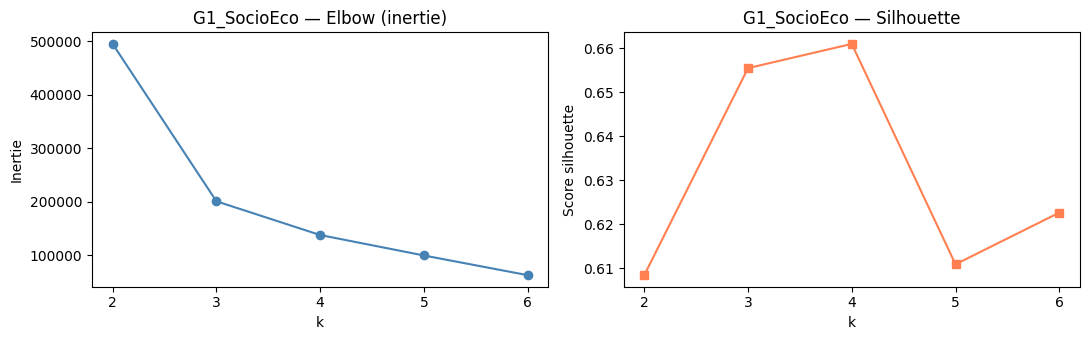

In [6]:
g = 'G1_SocioEco'
cols_g1 = [c for c in GROUPES[g] if c in X.columns]

Xs_g1_tmp = StandardScaler().fit_transform(X[cols_g1].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g1)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g1_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G1_SocioEco | k=3 | inertie=201,028
0    169701
1    254950
2    125320


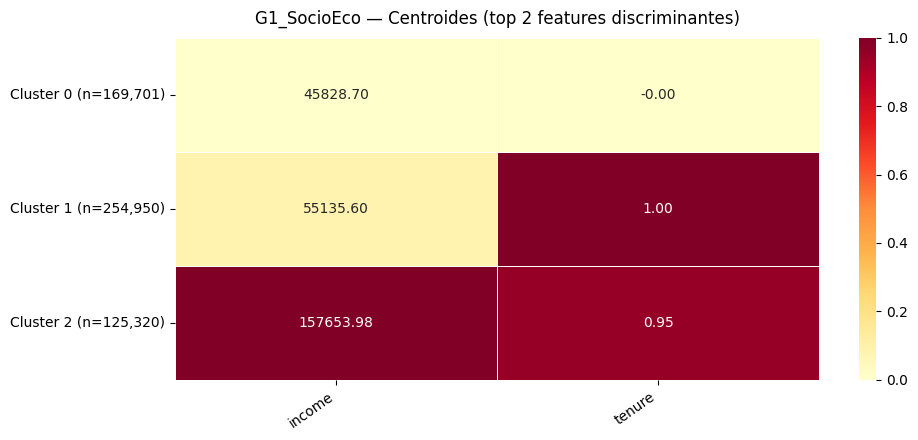

In [7]:
K_G1 = 3   # ← ajuster selon elbow

labels_g1, sc_g1, km_g1, Xs_g1 = cluster_group(X, cols_g1, K_G1, g)
analyse_cluster(X, cols_g1, labels_g1, km_g1, sc_g1, g)

In [8]:
# -- Analyse metier G1 : Socio-Economiques ------------------------------------
labels_metier_g1 = {
    0: "Locataires a revenus modestes   — subit les equipements, flexibilite contrainte",
    1: "Proprietaires a revenus moyens  — capacite d'investissement limitee",
    2: "Proprietaires aises             — fort potentiel adoption technologies flexibilite",
}
resume_clusters(labels_g1, km_g1, sc_g1, cols_g1, labels_metier_g1)


   Cluster   Effectif      %        income        tenure
--------------------------------------------------------
Cluster  0    169,701  30.9%      45828.70         -0.00 | Locataires a revenus modestes   — subit les equipements, flexibilite contrainte
Cluster  1    254,950  46.4%      55135.60          1.00 | Proprietaires a revenus moyens  — capacite d'investissement limitee
Cluster  2    125,320  22.8%     157653.98          0.95 | Proprietaires aises             — fort potentiel adoption technologies flexibilite


### G2 — Variables Occupants

Elbow / silhouette pour G2_Occupants (3 features) :


  k=2  inertie=950,458  silhouette=0.587


  k=3  inertie=628,247  silhouette=0.470


  k=4  inertie=415,739  silhouette=0.506


  k=5  inertie=294,891  silhouette=0.580


  k=6  inertie=252,293  silhouette=0.585


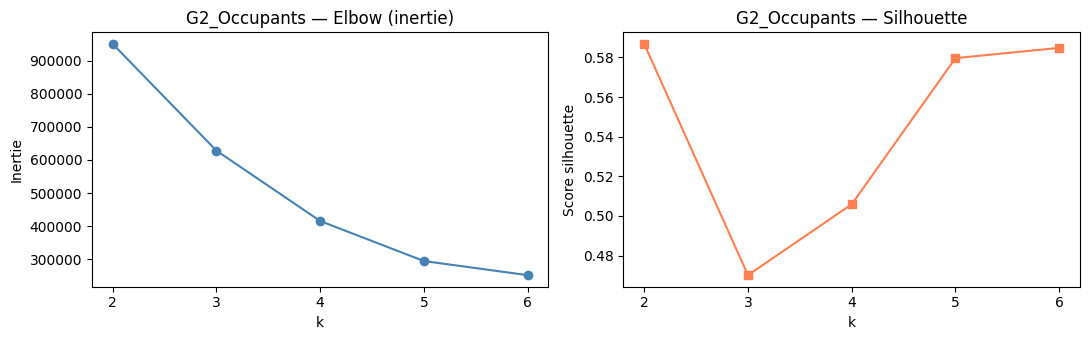

In [9]:
g = 'G2_Occupants'
cols_g2 = [c for c in GROUPES[g] if c in X.columns]

Xs_g2_tmp = StandardScaler().fit_transform(X[cols_g2].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g2)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g2_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G2_Occupants | k=3 | inertie=628,260
0    120757
1    362577
2     66637


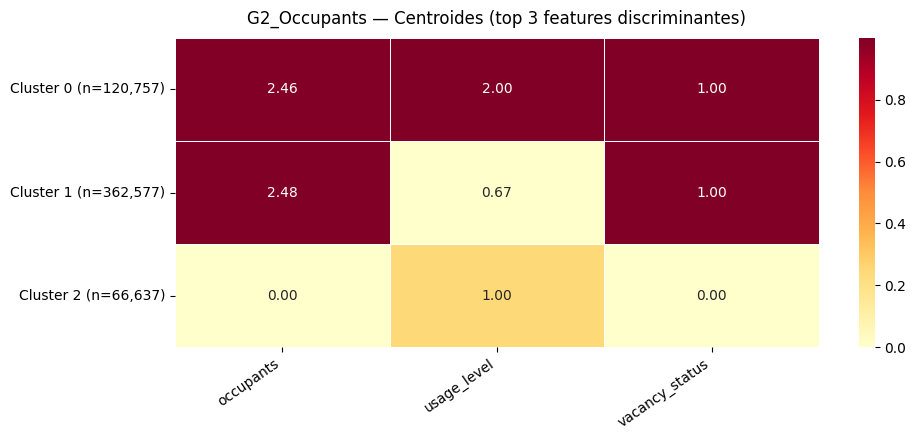

In [10]:
K_G2 = 3   # ← ajuster

labels_g2, sc_g2, km_g2, Xs_g2 = cluster_group(X, cols_g2, K_G2, g)
analyse_cluster(X, cols_g2, labels_g2, km_g2, sc_g2, g)

In [11]:
# -- Analyse metier G2 : Occupants --------------------------------------------
labels_metier_g2 = {
    0: "Foyers actifs a fort usage      — usage_level HIGH, potentiel delestage eleve",
    1: "Foyers a usage standard         — segment de reference majoritaire",
    2: "Logements vacants               — aucun occupant, consommation de base uniquement",
}
resume_clusters(labels_g2, km_g2, sc_g2, cols_g2, labels_metier_g2)


   Cluster   Effectif      %     occupants   usage_level  vacancy_status
------------------------------------------------------------------------
Cluster  0    120,757  22.0%          2.46          2.00          1.00 | Foyers actifs a fort usage      — usage_level HIGH, potentiel delestage eleve
Cluster  1    362,577  65.9%          2.48          0.67          1.00 | Foyers a usage standard         — segment de reference majoritaire
Cluster  2     66,637  12.1%          0.00          1.00          0.00 | Logements vacants               — aucun occupant, consommation de base uniquement


### G3 — Météo (Zone ASHRAE — stratum direct, pas KMeans)

In [12]:
# G3 : on charge la zone ASHRAE depuis metadata_clean (pas de KMeans)
meta = pd.read_parquet(DATA_PROCESSED / 'metadata_clean.parquet')
labels_g3 = meta['in.ashrae_iecc_climate_zone_2004'].values

print('G3 Météo — Distribution des zones ASHRAE :')
print(pd.Series(labels_g3).value_counts().sort_index().to_string())
print(f'\n{pd.Series(labels_g3).nunique()} zones climatiques distinctes')

G3 Météo — Distribution des zones ASHRAE :
1A       9855
2A      63763
2B      10859
3A      73177
3B      51101
3C      12894
4A     118416
4B       4252
4C      15840
5A     123952
5B      20841
6A      33724
6B       5077
7A       4343
7AK       969
7B        622
8AK       286

17 zones climatiques distinctes


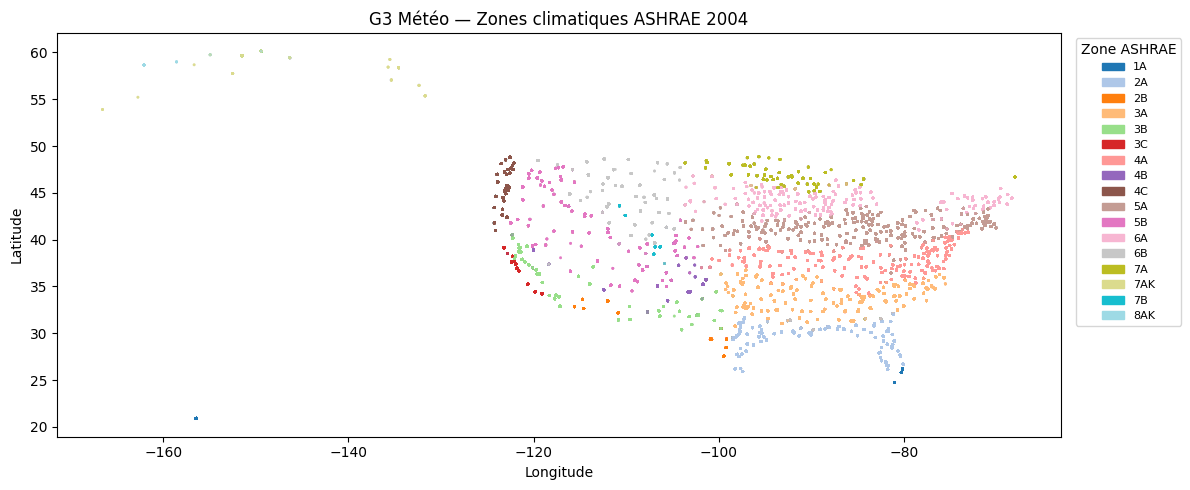

In [13]:
# Visualisation géographique des zones ASHRAE
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

zones   = pd.Series(labels_g3)
uniq    = sorted(zones.unique())
cmap    = plt.cm.get_cmap('tab20', len(uniq))
z2int   = {z: i for i, z in enumerate(uniq)}
colors  = zones.map(z2int)

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(
    meta['in.weather_file_longitude'], meta['in.weather_file_latitude'],
    c=colors, cmap=cmap, s=1, alpha=0.4, vmin=0, vmax=len(uniq)-1
)
patches = [mpatches.Patch(color=cmap(z2int[z]), label=z) for z in uniq]
ax.legend(handles=patches, title='Zone ASHRAE', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8)
ax.set(xlabel='Longitude', ylabel='Latitude',
       title='G3 Météo — Zones climatiques ASHRAE 2004')
plt.tight_layout()
plt.show()

In [14]:
# -- Analyse metier G3 : Meteo (ASHRAE) ---------------------------------------
zones_metier = {
    '1A': "Tres chaud humide (Miami, Houston)          — clim quasi permanente",
    '2A': "Chaud humide (Dallas, Atlanta)              — pic estival dominant",
    '3A': "Mixte chaud humide (Charlotte, Nashville)   — besoins chauffage + clim",
    '3B': "Chaud sec (Los Angeles, Las Vegas)          — clim seche, peu de chauffage",
    '3C': "Marin tempere (San Francisco)               — faibles besoins thermiques",
    '4A': "Mixte humide (DC, Baltimore)                — chauffage et clim equilibres",
    '4B': "Mixte sec (Albuquerque)                     — grands ecarts thermiques",
    '4C': "Marin froid (Seattle, Portland)             — chauffage modere",
    '5A': "Froid humide (Chicago, Detroit)             — chauffage dominant, pic hivernal",
    '5B': "Froid sec (Denver, Salt Lake City)          — chauffage fort, ete modere",
    '6A': "Tres froid humide (Minneapolis, Boston)     — chauffage tres dominant",
    '6B': "Tres froid sec (Montana, Idaho)             — conditions extremes",
    '7A': "Subarctique (Alaska, extreme Nord)          — chauffage quasi exclusif",
}
print("Zone ASHRAE — Interpretation metier")
print("-" * 75)
z_counts = pd.Series(labels_g3).value_counts().sort_index()
for zone, count in z_counts.items():
    pct  = count / len(labels_g3) * 100
    desc = zones_metier.get(zone, "Zone specifique")
    print(f"  {zone:5s}  {count:>7,} ({pct:4.1f}%)  {desc}")


Zone ASHRAE — Interpretation metier
---------------------------------------------------------------------------
  1A       9,855 ( 1.8%)  Tres chaud humide (Miami, Houston)          — clim quasi permanente
  2A      63,763 (11.6%)  Chaud humide (Dallas, Atlanta)              — pic estival dominant
  2B      10,859 ( 2.0%)  Zone specifique
  3A      73,177 (13.3%)  Mixte chaud humide (Charlotte, Nashville)   — besoins chauffage + clim
  3B      51,101 ( 9.3%)  Chaud sec (Los Angeles, Las Vegas)          — clim seche, peu de chauffage
  3C      12,894 ( 2.3%)  Marin tempere (San Francisco)               — faibles besoins thermiques
  4A     118,416 (21.5%)  Mixte humide (DC, Baltimore)                — chauffage et clim equilibres
  4B       4,252 ( 0.8%)  Mixte sec (Albuquerque)                     — grands ecarts thermiques
  4C      15,840 ( 2.9%)  Marin froid (Seattle, Portland)             — chauffage modere
  5A     123,952 (22.5%)  Froid humide (Chicago, Detroit)             — cha

### G4a — Isolation & Étanchéité

Elbow / silhouette pour G4a_Isolation (10 features) :


  k=2  inertie=4,663,848  silhouette=0.158


  k=3  inertie=4,226,346  silhouette=0.140


  k=4  inertie=3,763,431  silhouette=0.161


  k=5  inertie=3,462,840  silhouette=0.149


  k=6  inertie=3,271,283  silhouette=0.156


  k=7  inertie=2,949,962  silhouette=0.166


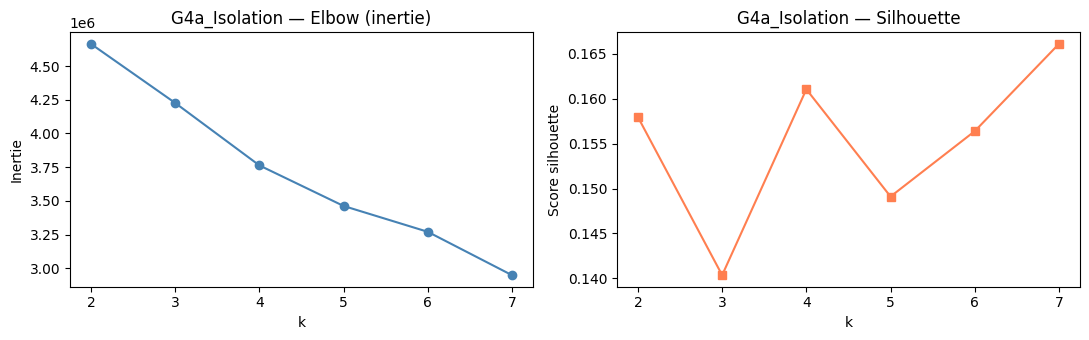

In [15]:
g = 'G4a_Isolation'
cols_g4a = [c for c in GROUPES[g] if c in X.columns]

Xs_g4a_tmp = StandardScaler().fit_transform(X[cols_g4a].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g4a)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g4a_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

G4a_Isolation | k=4 | inertie=4,013,910
0    212133
1     50427
2    101565
3    185846


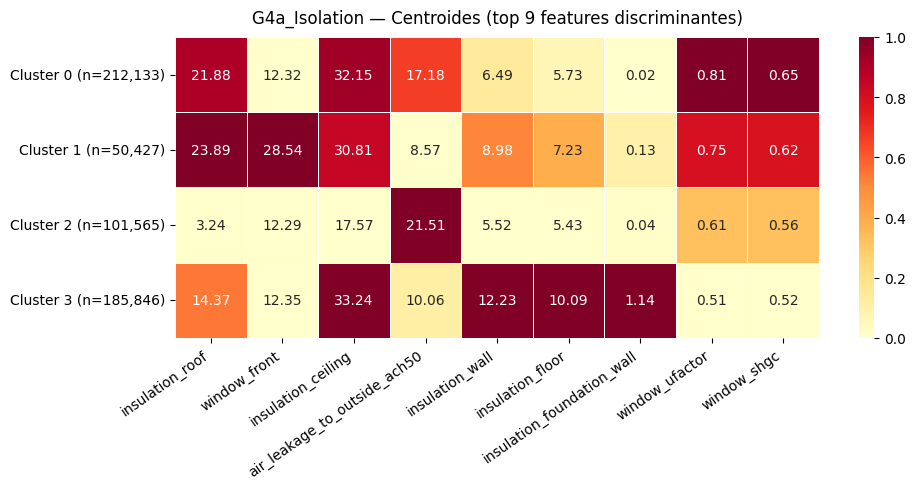


Elbow / silhouette pour G4b_Geometrie (14 features) :


  k=2  inertie=5,891,882  silhouette=0.287


  k=3  inertie=5,322,090  silhouette=0.150


  k=4  inertie=4,821,011  silhouette=0.177


  k=5  inertie=4,471,403  silhouette=0.185


  k=6  inertie=4,244,226  silhouette=0.149


  k=7  inertie=4,023,469  silhouette=0.161


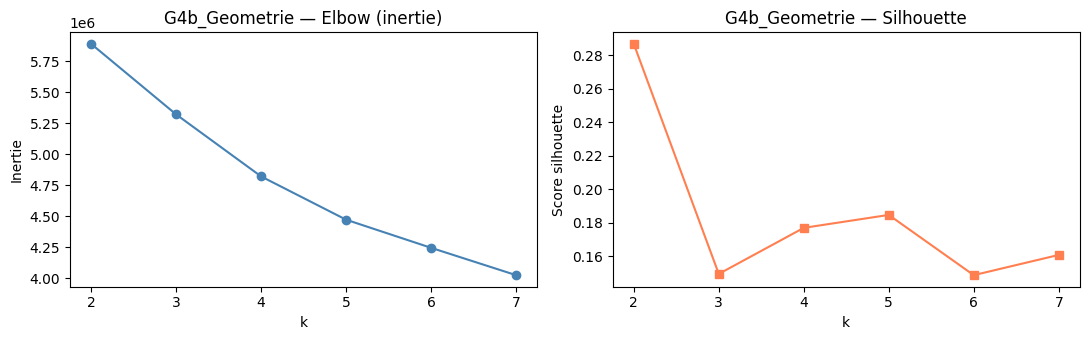

G4b_Geometrie | k=4 | inertie=4,832,013
0    220725
1    155324
2     69319
3    104603


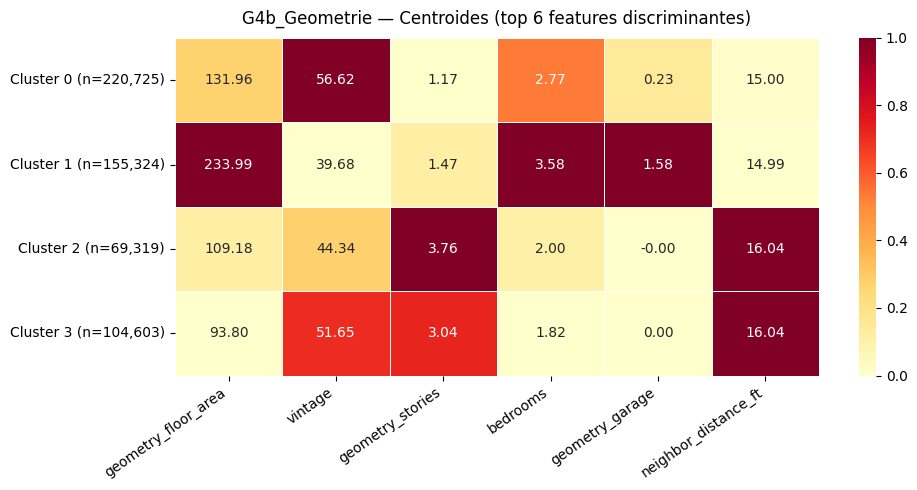

In [16]:
K_G4a = 4   # ← ajuster (ex: très mal isolé / mal isolé / standard / performant)

labels_g4a, sc_g4a, km_g4a, Xs_g4a = cluster_group(X, cols_g4a, K_G4a, g)
analyse_cluster(X, cols_g4a, labels_g4a, km_g4a, sc_g4a, g, n_top=9)

# ── G4b : Géométrie ───────────────────────────────────────────────────────────
g = 'G4b_Geometrie'
cols_g4b = [c for c in GROUPES[g] if c in X.columns]

Xs_g4b_tmp = StandardScaler().fit_transform(X[cols_g4b].astype(float).values)
print(f'\nElbow / silhouette pour {g} ({len(cols_g4b)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g4b_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

K_G4b = 4   # ← ajuster (ex: studio/petit / moyen / grand / très grand)

labels_g4b, sc_g4b, km_g4b, Xs_g4b = cluster_group(X, cols_g4b, K_G4b, g)
analyse_cluster(X, cols_g4b, labels_g4b, km_g4b, sc_g4b, g, n_top=6)

In [17]:
# -- Analyse metier G4a : Isolation & Etancheite ------------------------------
labels_metier_g4a = {
    0: "Combles renoves, murs anciens, tres permeable — renovation partielle annees 80",
    1: "Bien isole et etanche                         — maison renovee ou recente performante",
    2: "Tres mal isole, toiture non finie             — vieux multifamilial ou mobile home",
    3: "Tres bien isole tous postes                   — construction recente performante",
}
resume_clusters(labels_g4a, km_g4a, sc_g4a, cols_g4a, labels_metier_g4a)

print()
# -- Analyse metier G4b : Geometrie & Voisinage --------------------------------
labels_metier_g4b = {
    0: "Maison individuelle ancienne (annees 60-70)   — parc resididentiel majoritaire US",
    1: "Grande maison individuelle recente + garage   — consommation elevee, equipements modernes",
    2: "Immeuble collectif moyen (3-5 etages)         — couloir partiel, logements compacts",
    3: "Immeuble collectif avec couloir               — petits logements, chauffe-eau souvent partage",
}
resume_clusters(labels_g4b, km_g4b, sc_g4b, cols_g4b, labels_metier_g4b)


   Cluster   Effectif      %  insulation_roof  window_front  insulation_ceiling  air_leakage_to_outside_ach50  insulation_wall  insulation_floor
------------------------------------------------------------------------------------------------------------------------------------------------
Cluster  0    212,133  38.6%         21.88         12.32         32.15         17.18          6.49          5.73 | Combles renoves, murs anciens, tres permeable — renovation partielle annees 80
Cluster  1     50,427   9.2%         23.89         28.54         30.81          8.57          8.98          7.23 | Bien isole et etanche                         — maison renovee ou recente performante
Cluster  2    101,565  18.5%          3.24         12.29         17.57         21.51          5.52          5.43 | Tres mal isole, toiture non finie             — vieux multifamilial ou mobile home
Cluster  3    185,846  33.8%         14.37         12.35         33.24         10.06         12.23         10.09 | Tr

### G5a — HVAC

Elbow / silhouette pour G5a_HVAC (13 features) :


  k=2  inertie=6,136,179  silhouette=0.145


  k=3  inertie=5,404,846  silhouette=0.151


  k=4  inertie=4,834,721  silhouette=0.159


  k=5  inertie=4,565,268  silhouette=0.143


  k=6  inertie=4,296,021  silhouette=0.172


  k=7  inertie=4,184,199  silhouette=0.143


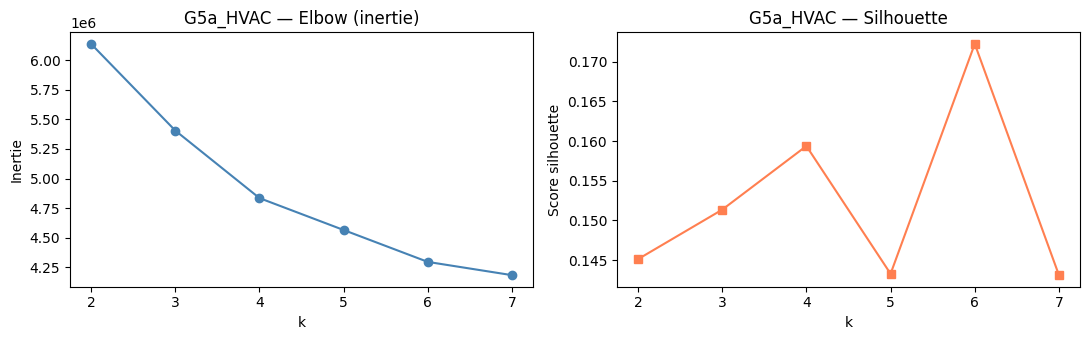

In [18]:
g = 'G5a_HVAC'
cols_g5a = [c for c in GROUPES[g] if c in X.columns]

Xs_g5a_tmp = StandardScaler().fit_transform(X[cols_g5a].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g5a)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g5a_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

G5a_HVAC | k=4 | inertie=4,835,177
0    115853
1    133480
2    185068
3    115570


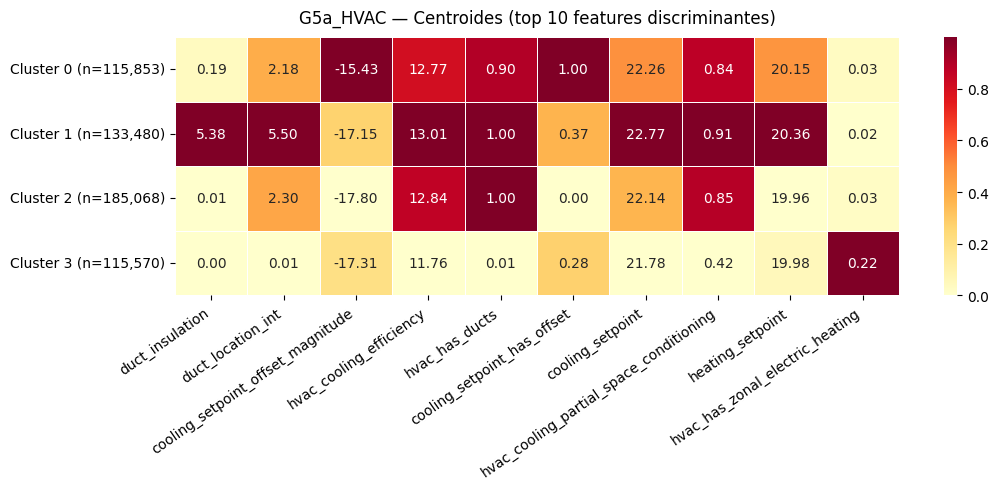


Elbow / silhouette pour G5b_ECS (10 features) :


  k=2  inertie=4,736,442  silhouette=0.225


  k=3  inertie=3,752,108  silhouette=0.269


  k=4  inertie=3,314,788  silhouette=0.320


  k=5  inertie=2,695,243  silhouette=0.346


  k=6  inertie=2,282,780  silhouette=0.367


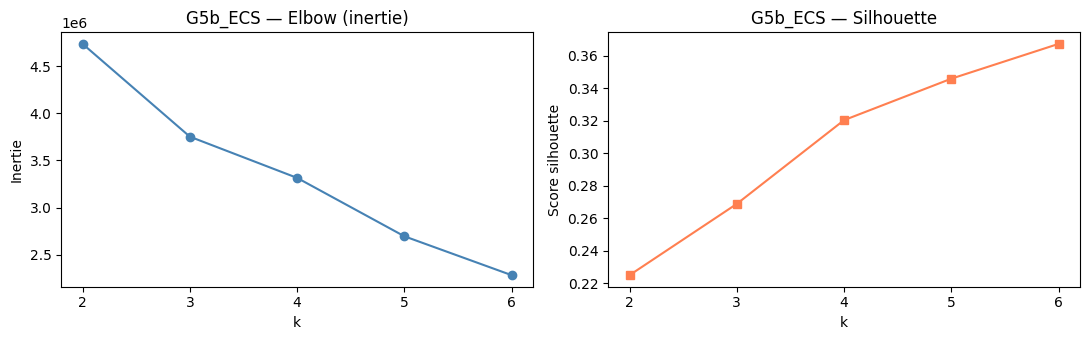

G5b_ECS | k=3 | inertie=3,752,025
0    232965
1     31988
2    285018


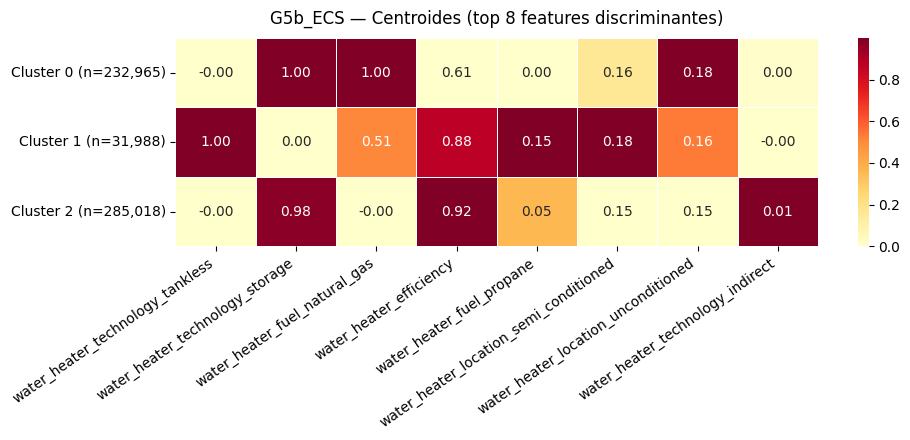

In [19]:
K_G5a = 4   # ← ajuster (ex: gaz/élec + thermostat programmable ou non)

labels_g5a, sc_g5a, km_g5a, Xs_g5a = cluster_group(X, cols_g5a, K_G5a, g)
analyse_cluster(X, cols_g5a, labels_g5a, km_g5a, sc_g5a, g, n_top=10)

# ── G5b : ECS ─────────────────────────────────────────────────────────────────
g = 'G5b_ECS'
cols_g5b = [c for c in GROUPES[g] if c in X.columns]

Xs_g5b_tmp = StandardScaler().fit_transform(X[cols_g5b].astype(float).values)
print(f'\nElbow / silhouette pour {g} ({len(cols_g5b)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g5b_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

K_G5b = 3   # ← ajuster (ex: élec standard / gaz standard / élec haute perf)

labels_g5b, sc_g5b, km_g5b, Xs_g5b = cluster_group(X, cols_g5b, K_G5b, g)
analyse_cluster(X, cols_g5b, labels_g5b, km_g5b, sc_g5b, g, n_top=8)

In [20]:
# -- Analyse metier G5a : HVAC ------------------------------------------------
labels_metier_g5a = {
    0: "Gaines + thermostat clim programme     — forte flexibilite refroidissement",
    1: "Gaines + sans programmation complete   — flexibilite limitee, signal prix peu efficace",
    2: "Gaines + aucun thermostat programme    — profil rigide, cible smart thermostat",
    3: "Pas de gaines, chauffage zonal elec    — profil tres different, resistif",
}
resume_clusters(labels_g5a, km_g5a, sc_g5a, cols_g5a, labels_metier_g5a)

print()
# -- Analyse metier G5b : ECS -------------------------------------------------
labels_metier_g5b = {
    0: "Ballon gaz naturel standard (EF~0.60)  — peu flexible, non pilotable electricement",
    1: "Chauffe-eau instantane                 — haute efficacite, pas de stockage thermique",
    2: "Ballon electrique (EF~0.92)            — CIBLE FLEXIBILITE : pilotable + stockage thermique",
}
resume_clusters(labels_g5b, km_g5b, sc_g5b, cols_g5b, labels_metier_g5b)


   Cluster   Effectif      %  duct_insulation  duct_location_int  cooling_setpoint_offset_magnitude  hvac_cooling_efficiency  hvac_has_ducts  cooling_setpoint_has_offset
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cluster  0    115,853  21.1%          0.19          2.18        -15.43         12.77          0.90          1.00 | Gaines + thermostat clim programme     — forte flexibilite refroidissement
Cluster  1    133,480  24.3%          5.38          5.50        -17.15         13.01          1.00          0.37 | Gaines + sans programmation complete   — flexibilite limitee, signal prix peu efficace
Cluster  2    185,068  33.7%          0.01          2.30        -17.80         12.84          1.00          0.00 | Gaines + aucun thermostat programme    — profil rigide, cible smart thermostat
Cluster  3    115,570  21.0%          0.00          0.01        -17.31    

### G6 — Usages Blancs (électroménager)

Elbow / silhouette pour G6_UsagesBlancs (19 features) :


  k=2  inertie=8,223,258  silhouette=0.295


  k=3  inertie=7,541,459  silhouette=0.154


  k=4  inertie=6,652,772  silhouette=0.207


  k=5  inertie=6,276,586  silhouette=0.176


  k=6  inertie=6,026,625  silhouette=0.160


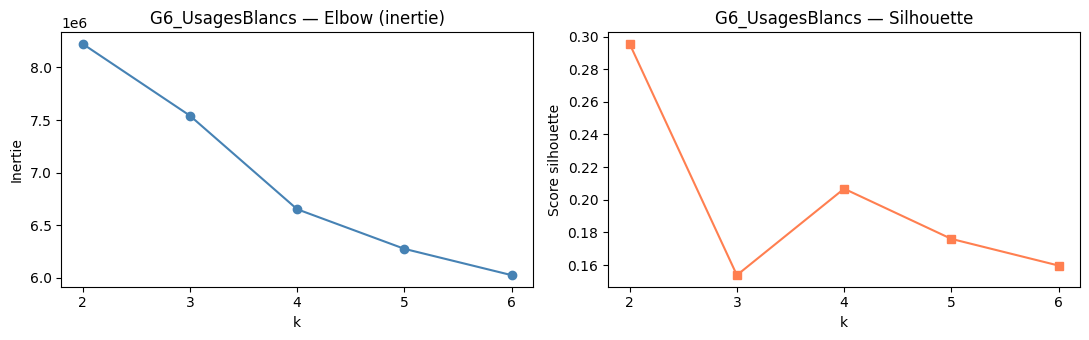

In [21]:
g = 'G6_UsagesBlancs'
cols_g6 = [c for c in GROUPES[g] if c in X.columns]

Xs_g6_tmp = StandardScaler().fit_transform(X[cols_g6].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g6)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g6_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G6_UsagesBlancs | k=3 | inertie=7,663,754
0     98778
1    169309
2    281884


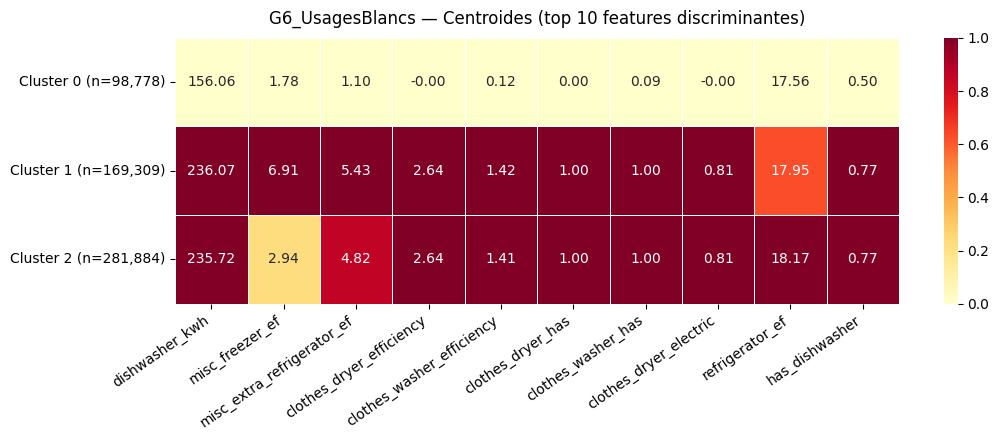

In [22]:
K_G6 = 3   # ← ajuster (ex: équipement basique / standard / premium)

labels_g6, sc_g6, km_g6, Xs_g6 = cluster_group(X, cols_g6, K_G6, g)
analyse_cluster(X, cols_g6, labels_g6, km_g6, sc_g6, g, n_top=10)

In [23]:
# -- Analyse metier G6 : Usages Blancs ----------------------------------------
labels_metier_g6 = {
    0: "Sans seche-linge, equipement minimal   — appartements collectifs, buanderie commune",
    1: "Equipement complet, usage intense      — fort potentiel effacement sur linge",
    2: "Equipement complet, usage modere       — segment de reference",
}
resume_clusters(labels_g6, km_g6, sc_g6, cols_g6, labels_metier_g6)


   Cluster   Effectif      %  dishwasher_kwh  misc_freezer_ef  misc_extra_refrigerator_ef  clothes_dryer_efficiency  clothes_washer_efficiency  clothes_dryer_has
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
Cluster  0     98,778  18.0%        156.06          1.78          1.10         -0.00          0.12          0.00 | Sans seche-linge, equipement minimal   — appartements collectifs, buanderie commune
Cluster  1    169,309  30.8%        236.07          6.91          5.43          2.64          1.42          1.00 | Equipement complet, usage intense      — fort potentiel effacement sur linge
Cluster  2    281,884  51.3%        235.72          2.94          4.82          2.64          1.41          1.00 | Equipement complet, usage modere       — segment de reference


### G7 — Usages Bruns (TV, PC, chargeurs)

Elbow / silhouette pour G7_UsagesBruns (2 features) :


  k=2  inertie=627,166  silhouette=0.530


  k=3  inertie=376,356  silhouette=0.492


  k=4  inertie=343,814  silhouette=0.432


  k=5  inertie=256,323  silhouette=0.482


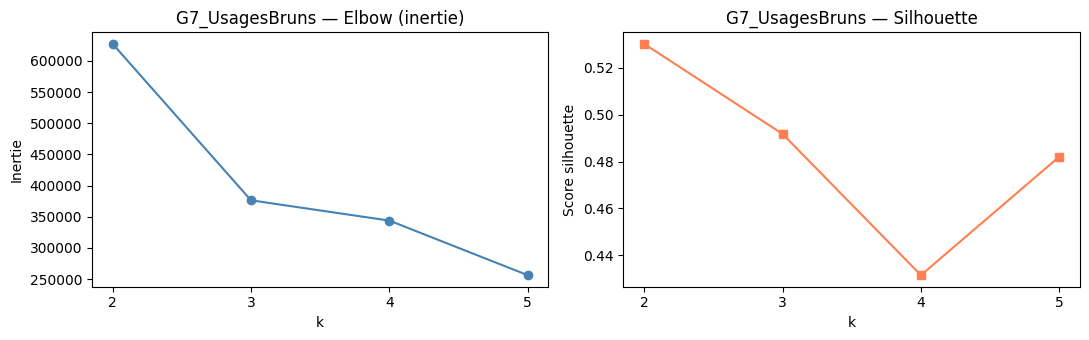

In [24]:
g = 'G7_UsagesBruns'
cols_g7 = [c for c in GROUPES[g] if c in X.columns]

Xs_g7_tmp = StandardScaler().fit_transform(X[cols_g7].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g7)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g7_tmp, range(2, 6), name=g)
plot_elbow(k_range, inertias, sils, g)

G7_UsagesBruns | k=3 | inertie=373,752
0    238483
1    133917
2    177571


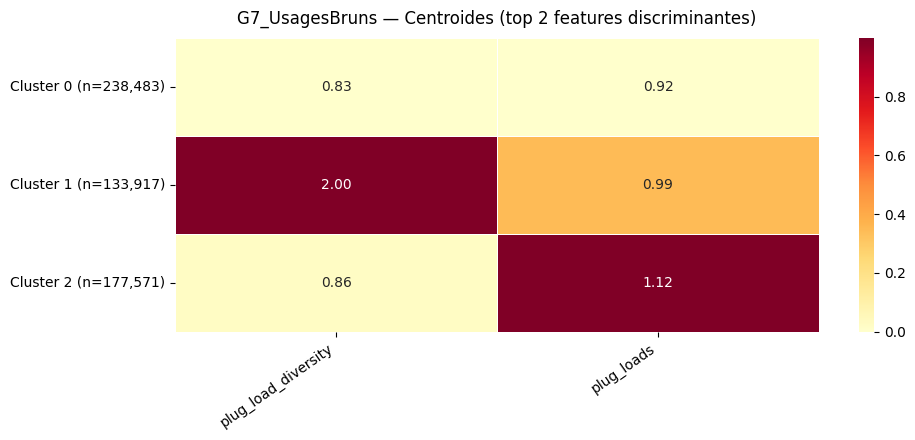

In [25]:
K_G7 = 3   # ← ajuster (ex: faible / moyen / fort usage bruns)

labels_g7, sc_g7, km_g7, Xs_g7 = cluster_group(X, cols_g7, K_G7, g)
analyse_cluster(X, cols_g7, labels_g7, km_g7, sc_g7, g, n_top=2)

In [26]:
# -- Analyse metier G7 : Usages Bruns -----------------------------------------
labels_metier_g7 = {
    0: "Faible charge brune, usage concentre  — peu d'appareils, pics prononces",
    1: "Charge standard                        — profil moyen de reference",
    2: "Charge elevee, usage diversifie        — nombreux appareils, etalement naturel des pics",
}
resume_clusters(labels_g7, km_g7, sc_g7, cols_g7, labels_metier_g7)


   Cluster   Effectif      %  plug_load_diversity    plug_loads
---------------------------------------------------------------
Cluster  0    238,483  43.4%          0.83          0.92 | Faible charge brune, usage concentre  — peu d'appareils, pics prononces
Cluster  1    133,917  24.3%          2.00          0.99 | Charge standard                        — profil moyen de reference
Cluster  2    177,571  32.3%          0.86          1.12 | Charge elevee, usage diversifie        — nombreux appareils, etalement naturel des pics


---
## 5. Agrégation des clusters → Stratum composite

On concatène les labels de **tous les groupes** pour former un stratum composite.  
Pour éviter l'explosion combinatoire, on fusionne les strata dont l'effectif est < seuil.

In [27]:
# ── Collecte de tous les labels ──────────────────────────────────────────────
labels_all = {
    'G1_SocioEco'    : labels_g1,
    'G2_Occupants'   : labels_g2,
    'G3_Meteo'       : labels_g3,   # labels ASHRAE (strings : '3A', '5B'...)
    'G4a_Isolation'  : labels_g4a,
    'G4b_Geometrie'  : labels_g4b,
    'G5a_HVAC'       : labels_g5a,
    'G5b_ECS'        : labels_g5b,
    'G6_UsagesBlancs': labels_g6,
    'G7_UsagesBruns' : labels_g7,
}

df_labels = pd.DataFrame({g: l for g, l in labels_all.items()})

# Stratum composite (chaîne)
cols_strat = list(labels_all.keys())
df_labels['stratum'] = (
    df_labels[cols_strat]
    .astype(str)
    .apply(lambda row: '_'.join(row), axis=1)
)

n_strata_raw = df_labels['stratum'].nunique()
print(f'Nombre de strata bruts : {n_strata_raw}')
print(f'\nDistribution (top 20) :')
print(df_labels['stratum'].value_counts().head(20).to_string())

Nombre de strata bruts : 32815

Distribution (top 20) :
stratum
1_1_5A_0_0_2_0_2_0    1772
1_1_5A_2_0_2_0_2_0    1656
1_1_2A_0_1_1_2_2_2    1399
2_1_3A_3_1_1_2_2_2    1292
2_1_5A_3_1_2_0_2_0    1279
1_1_3A_3_1_1_2_2_2    1228
1_1_3A_0_0_2_2_2_2    1172
2_1_2A_3_1_1_2_2_2    1112
2_1_3B_3_1_1_0_2_0    1110
2_1_5A_3_1_1_0_2_0    1079
0_1_5A_0_3_3_0_0_0    1056
2_1_2A_0_1_1_2_2_2    1003
1_1_5A_0_0_2_2_2_0     989
1_1_5A_3_0_2_0_2_0     986
0_1_5A_0_3_3_2_0_0     969
1_1_2A_3_1_1_2_2_2     955
1_1_4A_0_0_2_2_2_2     945
1_1_5A_0_0_0_0_2_0     933
1_1_2A_0_0_2_2_2_2     925
1_1_2A_2_0_1_2_2_2     924


In [28]:
# ── Fusion des strata rares ───────────────────────────────────────────────────
# Un stratum doit avoir au moins MIN_STRATUM_SIZE samples pour qu'un split 80/20
# puisse lui allouer au moins 1 sample dans le test set.

MIN_STRATUM_SIZE = max(10, int(len(X) * 0.0001))   # 0.01 % du dataset
print(f'Seuil minimum par stratum : {MIN_STRATUM_SIZE} samples')

counts = df_labels['stratum'].value_counts()
rare   = counts[counts < MIN_STRATUM_SIZE].index
print(f'Strata rares (< {MIN_STRATUM_SIZE}) : {len(rare)} / {len(counts)}')

# Remplacer les rares par 'RARE'
stratum_final = df_labels['stratum'].copy()
stratum_final[stratum_final.isin(rare)] = 'RARE'

print(f'Nombre de strata après fusion : {stratum_final.nunique()}')
print(f'Taille du stratum RARE : {(stratum_final == "RARE").sum():,} ({(stratum_final == "RARE").mean()*100:.1f}%)')

Seuil minimum par stratum : 54 samples
Strata rares (< 54) : 30616 / 32815


Nombre de strata après fusion : 2200
Taille du stratum RARE : 215,376 (39.2%)


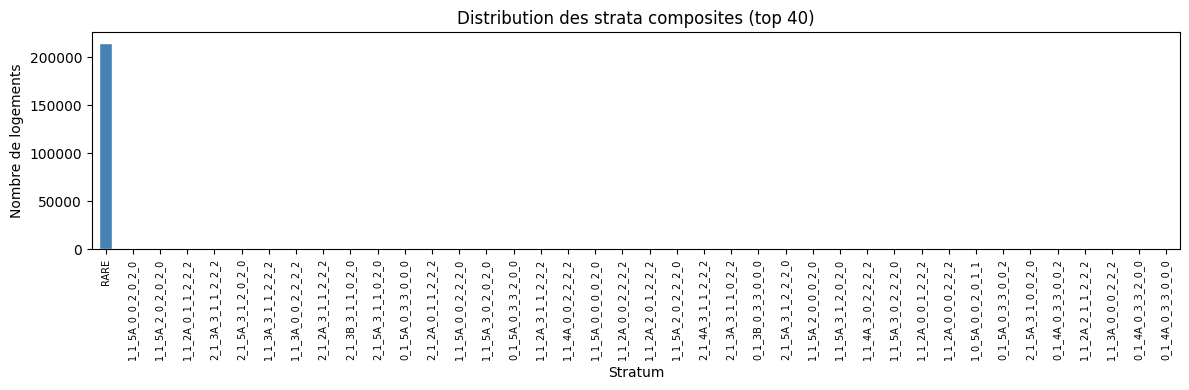

Strata couverts : 2200
Min / Médiane / Max : 54 / 100 / 215376


In [29]:
# ── Visualisation de la distribution des strata ───────────────────────────────
counts_final = stratum_final.value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
top_n = 40
counts_final.head(top_n).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set(title=f'Distribution des strata composites (top {top_n})',
       xlabel='Stratum', ylabel='Nombre de logements')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(f'Strata couverts : {stratum_final.nunique()}')
print(f'Min / Médiane / Max : {counts_final.min()} / {counts_final.median():.0f} / {counts_final.max()}')

---
## 6. Split Train / Test stratifié

In [30]:
idx = np.arange(len(X))

idx_train, idx_test = train_test_split(
    idx,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = stratum_final.values,
)

print(f'Train : {len(idx_train):,} ({len(idx_train)/len(X)*100:.1f}%)')
print(f'Test  : {len(idx_test):,}  ({len(idx_test)/len(X)*100:.1f}%)')

Train : 439,976 (80.0%)
Test  : 109,995  (20.0%)


In [31]:
# ── Validation de l'équilibre ─────────────────────────────────────────────────
# Pour chaque stratum, comparer la proportion train vs test

strat_train = stratum_final.iloc[idx_train].value_counts(normalize=True).rename('train')
strat_test  = stratum_final.iloc[idx_test].value_counts(normalize=True).rename('test')

df_check = pd.concat([strat_train, strat_test], axis=1).dropna()
df_check['diff_abs'] = (df_check['train'] - df_check['test']).abs()

print(f'Écart max train/test par stratum : {df_check["diff_abs"].max():.4f}')
print(f'Écart moyen                      : {df_check["diff_abs"].mean():.4f}')
print()
print('Top 10 strata les plus déséquilibrés :')
print(df_check.sort_values('diff_abs', ascending=False).head(10).to_string())

Écart max train/test par stratum : 0.0000
Écart moyen                      : 0.0000

Top 10 strata les plus déséquilibrés :
                       train      test  diff_abs
stratum                                         
2_1_3A_3_1_1_2_2_2  0.002348  0.002355  0.000007
1_1_5A_0_0_2_0_2_0  0.003221  0.003227  0.000007
RARE                0.391612  0.391618  0.000006
1_1_3A_0_0_2_2_2_2  0.002132  0.002127  0.000005
2_1_2A_3_1_1_2_2_2  0.002023  0.002018  0.000005
2_1_4A_3_1_1_2_2_2  0.001614  0.001609  0.000005
1_1_2A_0_0_1_2_2_2  0.001359  0.001355  0.000005
1_1_3A_0_0_0_2_2_2  0.001250  0.001246  0.000005
0_1_4A_0_3_3_2_0_0  0.001250  0.001246  0.000005
2_1_5A_2_0_2_0_2_0  0.001159  0.001155  0.000005


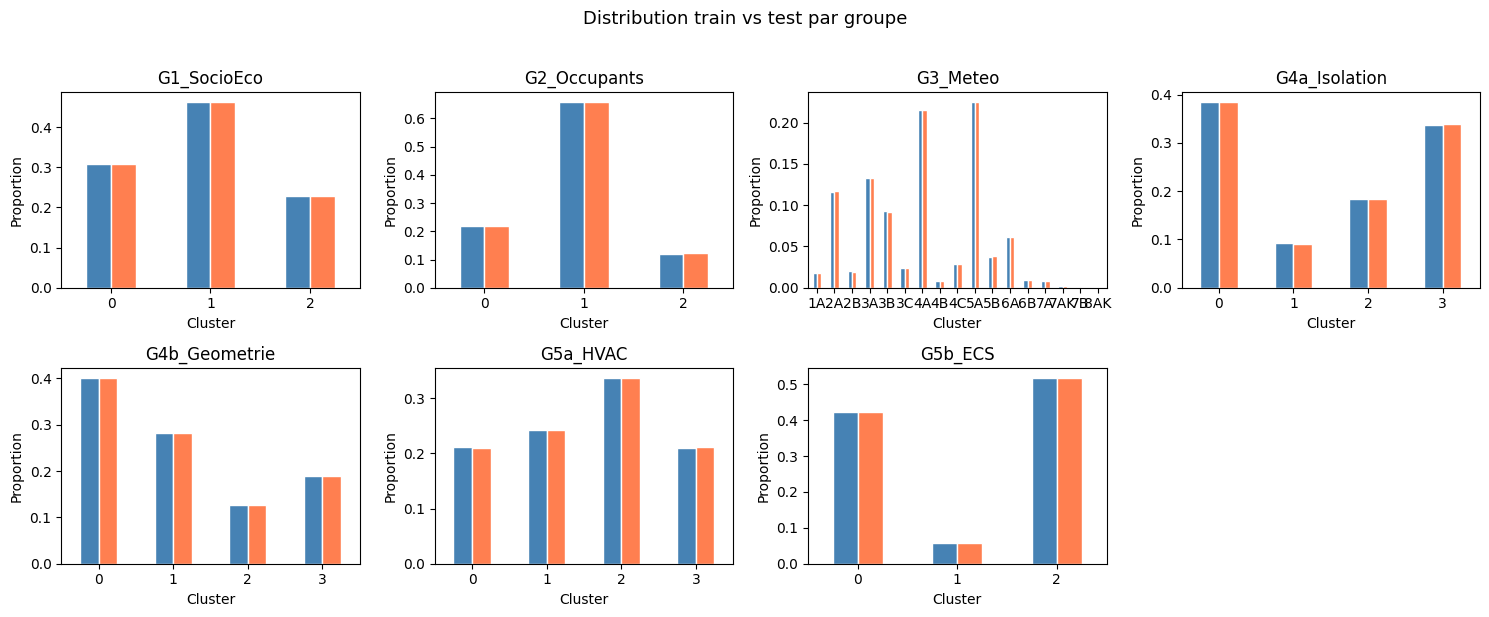

In [32]:
# ── Validation par groupe ─────────────────────────────────────────────────────
# Chaque cluster de chaque groupe doit être ~ 80 / 20 dans train / test

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for ax, (gname, labels) in zip(axes, labels_all.items()):
    s = pd.Series(labels)
    train_dist = s.iloc[idx_train].value_counts(normalize=True).sort_index()
    test_dist  = s.iloc[idx_test].value_counts(normalize=True).sort_index()
    df_g = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
    df_g.plot(kind='bar', ax=ax, color=['steelblue','coral'],
              edgecolor='white', legend=(gname == 'G1'))
    ax.set(title=gname, xlabel='Cluster', ylabel='Proportion')
    ax.tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)
plt.suptitle('Distribution train vs test par groupe', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Sauvegarde

In [33]:
# Indices
np.save(DATA_PROCESSED / 'idx_train.npy', idx_train)
np.save(DATA_PROCESSED / 'idx_test.npy',  idx_test)

# Labels de cluster par groupe + stratum final
df_labels['stratum_final'] = stratum_final.values
df_labels.to_parquet(DATA_PROCESSED / 'cluster_labels.parquet', index=False)

print('Sauvegardé :')
print(f'  idx_train.npy       → {len(idx_train):,} indices')
print(f'  idx_test.npy        → {len(idx_test):,} indices')
print(f'  cluster_labels.parquet → {df_labels.shape}')

Sauvegardé :
  idx_train.npy       → 439,976 indices
  idx_test.npy        → 109,995 indices
  cluster_labels.parquet → (549971, 11)


In [34]:
# ── Vérification rapide du split ──────────────────────────────────────────────
X_train = X.iloc[idx_train]
X_test  = X.iloc[idx_test]
Y_train = Y.iloc[idx_train]
Y_test  = Y.iloc[idx_test]

print('Split final :')
print(f'  X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'  Y_train : {Y_train.shape}  |  Y_test : {Y_test.shape}')
print()
print('Comparaison moyenne des cibles (train vs test) :')
comp = pd.DataFrame({'Train': Y_train.mean(), 'Test': Y_test.mean()})
comp['Diff %'] = ((comp['Test'] - comp['Train']) / comp['Train'] * 100).round(2)
print(comp.to_string())

Split final :
  X_train : (439976, 108)  |  X_test : (109995, 108)
  Y_train : (439976, 5)  |  Y_test : (109995, 5)

Comparaison moyenne des cibles (train vs test) :
                                                       Train          Test  Diff %
out.electricity.total.energy_consumption..kwh   11756.153943  11753.352880   -0.02
out.natural_gas.total.energy_consumption..kwh   10602.177020  10553.628869   -0.46
out.fuel_oil.total.energy_consumption..kwh       1276.967933   1295.724521    1.47
out.propane.total.energy_consumption..kwh        1106.843236   1090.641392   -1.46
out.emissions.total.lrmer_mid_case_25..co2e_kg   5429.158492   5419.642220   -0.18
